# MVP 2 — Audio → Trained Projection → SD-Turbo

**Pipeline**: audio → CLAP [512] → AudioProjection MLP (trained) → [77, 1024] → SD-Turbo UNet → image

No LLM at inference. The projection network learns to map audio embeddings directly into
SD-Turbo's text-conditioning space, supervised by CLIP text embeddings of GPT-4o-mini captions.

**Dependency order:**
1. `01_download_audio.py` — WAV files in `outputs/audio/`
2. `02_generate_prompts.py` — visual prompts in `outputs/prompts/`
3. `06_precompute_embeddings.py` — `.npy` files in `outputs/embeddings/`
4. `07_train_projection_modal.py` — checkpoint at `outputs/checkpoints/projection_best.pt`

In [2]:
# Cell 1 — Setup: load models and checkpoint
import sys, json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve() / 'scripts'))
from utils import load_filtered_df

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  device: {device}')

# ── AudioProjection (same architecture as training script) ─────────────────
class AudioProjection(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=1024, seq_len=77, out_dim=1024, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )
        self.pos_offsets = nn.Parameter(torch.zeros(seq_len, out_dim))

    def forward(self, x):   # [B, 512] → [B, 77, 1024]
        h = self.mlp(x)
        h = h.unsqueeze(1).expand(-1, 77, -1)
        return h + self.pos_offsets

# ── Load checkpoint or init fresh ─────────────────────────────────────────
CKPT_PATH = Path('../outputs/checkpoints/projection_best.pt')
projection = AudioProjection()

if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
    projection.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded checkpoint: epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.6f}')
else:
    print('No checkpoint found — using randomly initialized projection (run training first).')

projection = projection.to(device).eval()
param_count = sum(p.numel() for p in projection.parameters())
print(f'AudioProjection: {param_count/1e6:.1f}M parameters')

# ── Load CLAP ─────────────────────────────────────────────────────────────
from transformers import ClapModel, ClapProcessor
clap_model = ClapModel.from_pretrained('laion/clap-htsat-fused')
clap_processor = ClapProcessor.from_pretrained('laion/clap-htsat-fused')
clap_model.eval()
print(f'CLAP loaded  |  projection dim: {clap_model.config.projection_dim}')

# ── Load SD-Turbo ─────────────────────────────────────────────────────────
from diffusers import AutoPipelineForText2Image
pipe = AutoPipelineForText2Image.from_pretrained(
    'stabilityai/sd-turbo', torch_dtype=torch.float32
).to(device)
pipe.enable_attention_slicing()
print('SD-Turbo loaded')

PyTorch 2.11.0  |  device: mps
No checkpoint found — using randomly initialized projection (run training first).
AudioProjection: 2.7M parameters


/Users/aviudash/Code/classes/CS231N/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 477/477 [00:00<00:00, 5572.25it/s]


CLAP loaded  |  projection dim: 512


`Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/Users/aviudash/Code/classes/CS231N/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 15.11it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases t

SD-Turbo loaded


Running UMAP on 29 embeddings...


/Users/aviudash/Code/classes/CS231N/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


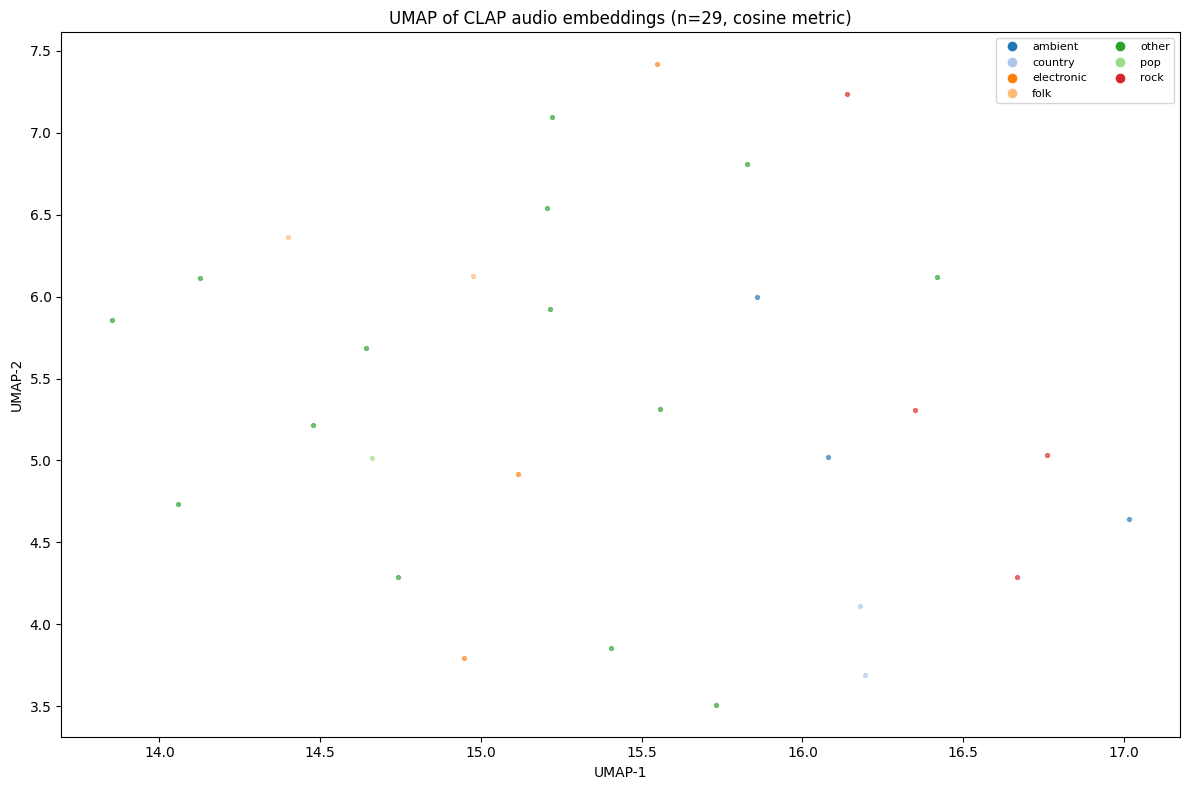

Genre distribution: {'other': 14, 'rock': 4, 'ambient': 3, 'electronic': 3, 'country': 2, 'folk': 2, 'pop': 1}


In [3]:
# Cell 2 — Embedding visualization: UMAP of CLAP audio embeddings colored by genre
# Requires: pip install umap-learn
# Shows that audio embeddings cluster by genre *before* training — confirms signal exists.

import umap
from matplotlib.lines import Line2D

EMB_AUDIO_DIR = Path('../outputs/embeddings/audio')
CSV_PATH = Path('../datasets/musiccaps-public.csv')

df = load_filtered_df(CSV_PATH)

# load all available embeddings
rows, embs = [], []
for _, row in df.iterrows():
    p = EMB_AUDIO_DIR / f"{row['ytid']}.npy"
    if p.exists():
        embs.append(np.load(p).astype(np.float32))
        rows.append(row)

if len(embs) < 5:
    print(f'Only {len(embs)} embeddings found. Run 06_precompute_embeddings.py first.')
else:
    X = np.stack(embs)
    print(f'Running UMAP on {len(X)} embeddings...')
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    X_2d = reducer.fit_transform(X)

    # normalize hyphens → spaces so 'hip-hop' matches keyword 'hip hop'
    GENRE_KEYWORDS = ['jazz', 'hip hop', 'rock', 'electronic', 'classical', 'folk', 'metal',
                      'ambient', 'pop', 'reggae', 'funk', 'r&b', 'country', 'blues']
    COLORS = plt.cm.tab20.colors

    genre_labels = []
    for row in rows:
        tags_normalized = [t.lower().replace('-', ' ') for t in row['aspect_list_parsed']]
        matched = next((g for g in GENRE_KEYWORDS if any(g in t for t in tags_normalized)), 'other')
        genre_labels.append(matched)

    genres = sorted(set(genre_labels))
    color_map = {g: COLORS[i % len(COLORS)] for i, g in enumerate(genres)}
    label_arr = np.array(genre_labels)

    fig, ax = plt.subplots(figsize=(12, 8))
    for g in genres:
        mask = label_arr == g
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color_map[g]], s=8, alpha=0.6)

    legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[g],
                              markersize=8, label=g) for g in genres]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8, ncol=2)
    ax.set_title(f'UMAP of CLAP audio embeddings (n={len(X)}, cosine metric)')
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.tight_layout(); plt.show()
    print(f'Genre distribution: {dict(sorted({g: genre_labels.count(g) for g in genres}.items(), key=lambda x: -x[1]))}')

Found 9 paired embeddings


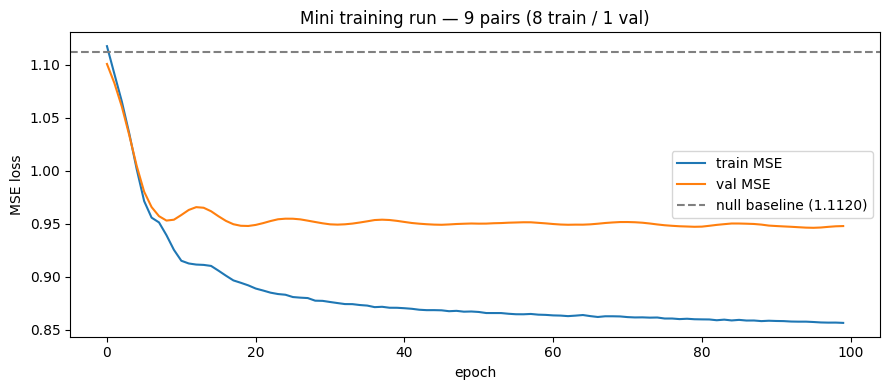

Final  train=0.856297  val=0.947733  null=1.111999


In [4]:
# Cell 3 — Mini training run on available pairs (works with as few as 2 pairs)
# Purpose: verify the training loop works end-to-end; plot loss curve.
# For real training use: modal run scripts/07_train_projection_modal.py

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

EMB_AUDIO_DIR = Path('../outputs/embeddings/audio')
EMB_TEXT_DIR = Path('../outputs/embeddings/text')

audio_files = {p.stem for p in EMB_AUDIO_DIR.glob('*.npy')} if EMB_AUDIO_DIR.exists() else set()
text_files = {p.stem for p in EMB_TEXT_DIR.glob('*.npy')} if EMB_TEXT_DIR.exists() else set()
pairs = sorted(audio_files & text_files)

print(f'Found {len(pairs)} paired embeddings')

if len(pairs) < 2:
    print('Need at least 2 pairs. Run 01, 02, then 06 first.')
else:
    audio_arr = np.stack([np.load(EMB_AUDIO_DIR / f'{y}.npy').astype(np.float32) for y in pairs])
    text_arr  = np.stack([np.load(EMB_TEXT_DIR  / f'{y}.npy').astype(np.float32) for y in pairs])

    xa = torch.tensor(audio_arr).to(device)
    xt = torch.tensor(text_arr).to(device)

    n = len(pairs)
    n_val = max(1, n // 5)
    n_train = n - n_val

    mini_proj = AudioProjection().to(device)
    optimizer = torch.optim.AdamW(mini_proj.parameters(), lr=3e-4, weight_decay=1e-4)
    criterion = nn.MSELoss()

    MINI_EPOCHS = 100
    train_losses, val_losses = [], []

    for epoch in range(1, MINI_EPOCHS + 1):
        mini_proj.train()
        pred = mini_proj(xa[:n_train])
        loss = criterion(pred, xt[:n_train])
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_losses.append(loss.item())

        mini_proj.eval()
        with torch.no_grad():
            val_loss = criterion(mini_proj(xa[n_train:]), xt[n_train:]).item()
        val_losses.append(val_loss)

    # null baseline: predict zeros → MSE = mean(||xt||^2)
    null_mse = (xt**2).mean().item()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_losses, label='train MSE', linewidth=1.5)
    ax.plot(val_losses, label='val MSE', linewidth=1.5)
    ax.axhline(null_mse, color='gray', linestyle='--', label=f'null baseline ({null_mse:.4f})')
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss')
    ax.set_title(f'Mini training run — {n} pairs ({n_train} train / {n_val} val)')
    ax.legend(); plt.tight_layout(); plt.show()

    print(f'Final  train={train_losses[-1]:.6f}  val={val_losses[-1]:.6f}  null={null_mse:.6f}')

100%|██████████| 4/4 [00:33<00:00,  8.29s/it]


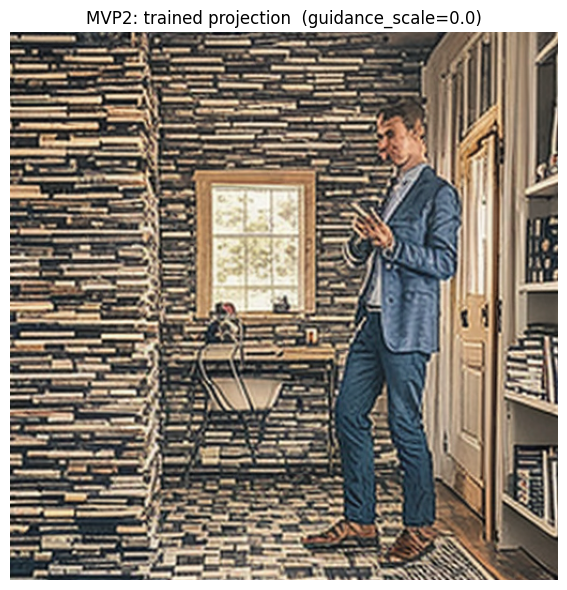

In [7]:
# Cell 4 — Inference: any WAV → image via trained projection
# Set AUDIO_PATH to any .wav file (or .mp3 — librosa handles both)

import librosa
import torch.nn.functional as F

AUDIO_PATH = '../outputs/audio/-5FoeegAgvU.wav'   # <-- set this
CLAP_SR = 48000
MAX_SEC = 10


def _clap_audio_emb(inputs):
    """Extract [1, 512] CLAP audio embedding regardless of transformers version.
    get_audio_features() returns BaseModelOutputWithPooling in some versions, a tensor in others.
    pooler_output is already projection-applied → 512 dims in either case.
    """
    out = clap_model.get_audio_features(**inputs)
    return out.pooler_output if hasattr(out, "pooler_output") else out


def audio_to_image(wav_path: str, guidance_scale: float = 0.0):
    """Full MVP2 pipeline: WAV → CLAP → projection → SD-Turbo → PIL image."""
    arr, _ = librosa.load(wav_path, sr=CLAP_SR, mono=True)
    mid = len(arr) // 2
    half = int(MAX_SEC * CLAP_SR / 2)
    arr = arr[max(0, mid - half): mid + half]

    with torch.no_grad():
        inputs = clap_processor(audio=[arr], sampling_rate=CLAP_SR, return_tensors='pt')
        audio_emb = _clap_audio_emb(inputs)                        # [1, 512]
        audio_emb = F.normalize(audio_emb, dim=-1).to(device)

        cond = projection(audio_emb).to(torch.float32)             # [1, 77, 1024]

        uncond = torch.zeros_like(cond) if guidance_scale > 0 else None

        image = pipe(
            prompt_embeds=cond,
            negative_prompt_embeds=uncond,
            num_inference_steps=4,
            guidance_scale=guidance_scale,
            width=512, height=512,
        ).images[0]

    return image


if Path(AUDIO_PATH).exists():
    img = audio_to_image(AUDIO_PATH)
    plt.figure(figsize=(6, 6))
    plt.imshow(img); plt.axis('off')
    plt.title('MVP2: trained projection  (guidance_scale=0.0)')
    plt.tight_layout(); plt.show()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
else:
    print(f'Set AUDIO_PATH to a valid WAV/MP3 file.')

In [ ]:
# Cell 5 — Side-by-side: MVP1 (retrieval) vs MVP2 (trained projection)
# Also computes CLIP-T score for each image (cosine sim between CLIP image feat and text feat of visual_prompt)

from PIL import Image
from transformers import CLIPModel, CLIPProcessor

COMPARE_AUDIO = '/path/to/your/clip.wav'   # <-- set this

PROMPT_LIBRARY_SAMPLE = [
    {'music_description': 'melancholic jazz with a solo saxophone, slow brushed drums, upright bass, and a late-night blue mood',
     'visual_prompt': 'a lone saxophone player in a dimly lit jazz bar, warm amber light, cigarette smoke curling, rain streaking the window, impressionist oil painting'},
    {'music_description': 'aggressive hip hop with heavy 808 bass, hard trap beats, rapid hi-hats, and intense rap vocals',
     'visual_prompt': 'urban street art explosion, graffiti murals towering over a night alley, bold primary colors, raw energy, city power'},
    {'music_description': 'peaceful ambient music with slow evolving pads, gentle bells, and a serene meditative atmosphere',
     'visual_prompt': 'a serene misty Japanese garden at dawn, still reflecting pond, lotus flowers, soft pastel watercolors, peaceful silence'},
    {'music_description': 'heavy metal with distorted down-tuned guitars, double bass drum blasts, aggressive vocals, and an intense crushing energy',
     'visual_prompt': 'a volcanic eruption at night, rivers of molten lava, lightning splitting the sky, dramatic chiaroscuro, raw elemental fury'},
    {'music_description': 'acoustic folk music with fingerpicked guitar, warm vocals, and a nostalgic rural storytelling feeling',
     'visual_prompt': 'rolling green Irish countryside at sunset, wildflowers, dry stone walls, golden hour light, rustic cottage, warm watercolor'},
]


def mvp1_image(wav_path: str) -> tuple:
    """MVP1: CLAP cosine nearest-neighbor → SD-Turbo."""
    arr, _ = librosa.load(wav_path, sr=CLAP_SR, mono=True)
    mid = len(arr) // 2; half = int(MAX_SEC * CLAP_SR / 2)
    arr = arr[max(0, mid - half): mid + half]

    music_descs = [p['music_description'] for p in PROMPT_LIBRARY_SAMPLE]
    with torch.no_grad():
        a_inp = clap_processor(audio=[arr], sampling_rate=CLAP_SR, return_tensors='pt')
        a_emb = F.normalize(_clap_audio_emb(a_inp), dim=-1)   # [1, 512]

        t_out = clap_model.get_text_features(
            **clap_processor(text=music_descs, return_tensors='pt', padding=True)
        )
        t_emb = t_out.pooler_output if hasattr(t_out, 'pooler_output') else t_out
        t_emb = F.normalize(t_emb, dim=-1)                     # [N, 512]

    sims = (a_emb @ t_emb.T).squeeze(0)
    best = sims.argmax().item()
    visual_prompt = PROMPT_LIBRARY_SAMPLE[best]['visual_prompt']

    img = pipe(visual_prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
    return img, visual_prompt


def clip_t_score(image: Image.Image, text: str, clip_model, clip_proc) -> float:
    """CLIP-T: cosine similarity between image and text features."""
    with torch.no_grad():
        img_inp = clip_proc(images=image, return_tensors='pt')
        txt_inp = clip_proc(text=[text], return_tensors='pt', padding=True, truncation=True)
        img_feat = F.normalize(clip_model.get_image_features(**img_inp), dim=-1)
        txt_feat = F.normalize(clip_model.get_text_features(**txt_inp), dim=-1)
    return (img_feat @ txt_feat.T).item()


if Path(COMPARE_AUDIO).exists():
    clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
    clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
    clip_model.eval()

    print('Generating MVP1 image...')
    img1, prompt1 = mvp1_image(COMPARE_AUDIO)
    score1 = clip_t_score(img1, prompt1, clip_model, clip_proc)

    print('Generating MVP2 image...')
    img2 = audio_to_image(COMPARE_AUDIO)
    score2 = clip_t_score(img2, prompt1, clip_model, clip_proc)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img1); axes[0].axis('off')
    axes[0].set_title(f'MVP1: retrieval\nCLIP-T={score1:.3f}', fontsize=11)
    axes[1].imshow(img2); axes[1].axis('off')
    axes[1].set_title(f'MVP2: trained projection\nCLIP-T={score2:.3f}', fontsize=11)
    plt.suptitle(Path(COMPARE_AUDIO).name, fontsize=13)
    plt.tight_layout(); plt.show()
    print(f'\nCLIP-T  MVP1={score1:.3f}  MVP2={score2:.3f}  delta={score2-score1:+.3f}')
else:
    print('Set COMPARE_AUDIO to a valid WAV/MP3 file.')

In [ ]:
# Cell 6 — Ablation: guidance_scale sweep (0.0, 3.0, 7.5)
# The projection outputs conditioning in CLIP text space. With guidance_scale > 0,
# SD uses CFG with zeros as the uncond embedding — this can amplify or suppress features.
# CFG was designed for text embeddings, not audio projections, so the sweet spot may differ.

ABLATION_AUDIO = '/path/to/your/clip.wav'   # <-- set this
GUIDANCE_SCALES = [0.0, 3.0, 7.5]

if Path(ABLATION_AUDIO).exists():
    images = []
    for gs in GUIDANCE_SCALES:
        print(f'Generating with guidance_scale={gs}...')
        img = audio_to_image(ABLATION_AUDIO, guidance_scale=gs)
        images.append(img)
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()

    fig, axes = plt.subplots(1, len(GUIDANCE_SCALES), figsize=(6 * len(GUIDANCE_SCALES), 6))
    for ax, img, gs in zip(axes, images, GUIDANCE_SCALES):
        ax.imshow(img); ax.axis('off')
        ax.set_title(f'guidance_scale={gs}', fontsize=12)
    plt.suptitle(f'CFG ablation — MVP2  |  {Path(ABLATION_AUDIO).name}', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('Set ABLATION_AUDIO to a valid WAV/MP3 file.')